Testing the idea of using Virtual distillation on two modes with an ancilla qubit

In [41]:
#Run B matrix circuit on various input states
using QuantumOptics
using Plots
using LinearAlgebra
println(Threads.nthreads())
println(Sys.CPU_THREADS)
println(BLAS.get_num_threads())
BLAS.set_num_threads(1)
println(BLAS.get_num_threads())

b_spin = SpinBasis(1//2)
b_motion = FockBasis(50)
b_coll_2m = b_spin ⊗ b_motion 


const sx = sigmax(b_spin)
const sy = sigmay(b_spin)
const sz = sigmaz(b_spin)
const sp = (sx + 1im*sy)/2
const sm = (sx - 1im*sy)/2

const up = spinup(b_spin)
const down = spindown(b_spin)
const I_s = identityoperator(b_spin)

const ad = create(b_motion)
const a = destroy(b_motion)
const I_m = identityoperator(b_motion)
const n = QuantumOptics.number(b_motion)


function squeeze_one(r=0.5, θ=0)
    """ squeeze one mode """
    ξ = r*exp(1im*θ*2)
    # Squeeze the first mode
    S = exp(1/2 * (conj(ξ)*a^2 - ξ*ad^2))
    return S
end

function trisqueeze_one(r=0.5, θ=0)
    """ trisqueeze one mode """
    ξ = r*exp(1im*θ*2)
    # Squeeze the first mode
    T = exp(1/2 * (conj(ξ)*a^3 - ξ*ad^3))
    return T
end

const P_down = dm(down)
const P_up = dm(up)

const Hadamard = (sx + sz) / sqrt(2)
const H_ancilla = tensor(Hadamard, I_m )
const S_ancilla = tensor(exp(1im*pi/4*sz), I_m )

function D(beta)
    """ displacement propagator """
    return exp(beta * ad - conj(beta) * a)
end


function sdf(beta)
    """ spin dependent force """
    return P_up ⊗ D(beta)  +
            P_down ⊗ D(-beta)
end

const spin_up_state = dm(up) ⊗ I_m
const spin_down_state = dm(down) ⊗ I_m
function measure_spin(a)
    return real(expect(spin_up_state, a)) - real(expect(spin_down_state, a))
end

function get_chi_psi(psi, beta; do_re=true)
    " get single characteristic function value for state psi and point beta "
    if do_re
        U = H_ancilla * sdf(beta) * H_ancilla
    else
        U = H_ancilla *S_ancilla* sdf(beta) * H_ancilla
    end
    psi_out = U * psi
    return measure_spin(psi_out)
end

function get_linear_range(beta_min, beta_max, num_points)
    linear_range = LinRange(beta_min, beta_max, num_points)
    return linear_range
end

linear_range = get_linear_range(-1.5, 1.5, 5)


function get_characteristic_function_psi(psi, beta_max, num_points; do_re=true)
    beta_real_range = linear_range
    beta_imag_range = linear_range

    chi_arr = zeros(ComplexF64, num_points, num_points)

    Threads.@threads for idx in 1:(num_points * num_points)
        i = div(idx - 1, num_points) + 1
        j = mod(idx - 1, num_points) + 1

        beta = beta_real_range[i] + 1im * beta_imag_range[j]
        chi_arr[i, j] = get_chi_psi(psi, beta; do_re=do_re)
    end

    return chi_arr
end

function plot_char_fn(chi_arr, title_str, axis_labels, axis_ticks)
    max_val = maximum(abs.(chi_arr))
    p = heatmap(linear_range, linear_range, real.(chi_arr), c=cgrad(:balance), aspect_ratio=:equal, xlabel=axis_labels[1], ylabel=axis_labels[2], title=title_str, xticks=axis_ticks[1], yticks=axis_ticks[2], clims=(-max_val, max_val))
    return p
end

function check_w_norm(w)
    # Check that the Wigner function is properly normalized by integrating over the entire phase space
    dx = (linear_range[2] - linear_range[1])
    dy = (linear_range[2] - linear_range[1])
    integral = sum(w) * dx * dy
    println("Integral of Wigner function over phase space: ", integral)
end

function plot_wigner(state, lim=3)
    w = wigner(state, linear_range, linear_range); 
    check_w_norm(w)   

    max_val = maximum(abs.(w))
    axis_scale = linear_range
    lim = maximum(abs.(axis_scale))
    w_plt = heatmap(axis_scale, axis_scale, w, c=:balance,aspect_ratio=:equal,  xlabel="Re(γ)", ylabel="Im(γ)",  clims=(-max_val, max_val), xlims=(-lim, lim), ylims=(-lim, lim))
    plot(w_plt)
    hline!([0], color=:black, linestyle=:dash)
    vline!([0], color=:black, linestyle=:dash)
    hline!([-0.5, 0.5], color=:grey, linestyle=:dash)
    vline!([-0.5, 0.5], color=:grey, linestyle=:dash, legend=false)
end


1
16
1
1


plot_wigner (generic function with 2 methods)

First look at pure states to debug the derangement and characteristic function circuit

Integral of Wigner function over phase space: 0.9954857861346283


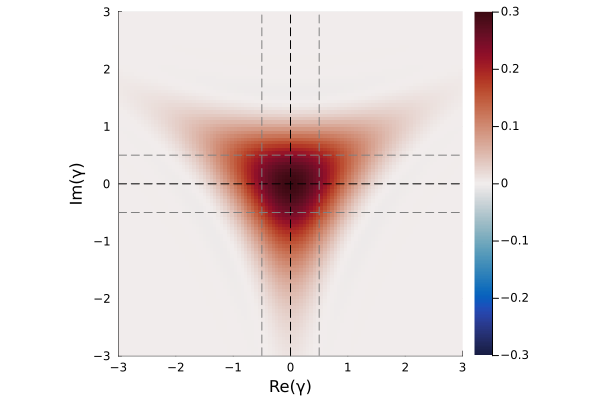

In [42]:
beta_min = -3.0
beta_max = 3.0
num_points = 101
linear_range = get_linear_range(beta_min, beta_max, num_points)

phi_2 = -3*pi/2
#phi_2 = pi/2
S = 0.15
fock_init = 0
psi_m = fockstate(b_motion, fock_init)
psi_m = trisqueeze_one(S, 0)*psi_m

psi_hybrid = tensor(up, psi_m)
beta_1 = 0.0 + 0.0im
psi_hybrid = sdf(beta_1)*psi_hybrid
rho_m1 = ptrace(psi_hybrid, [1])
m1_w = plot_wigner(rho_m1)

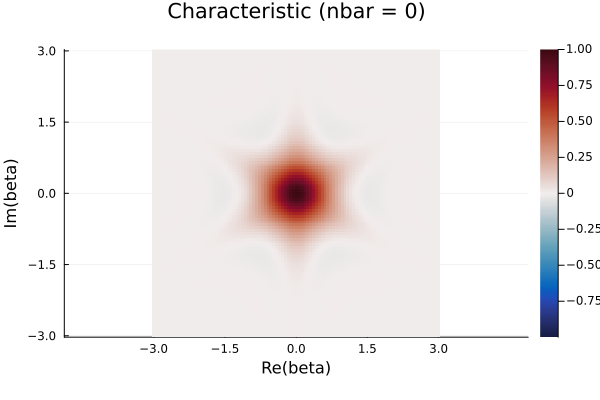

In [43]:
"""Plot real part """
axis_ticks = (LinRange(beta_min, beta_max, 5), LinRange(beta_min, beta_max, 5))

axis_labels = ("Re(beta)", "Im(beta)")
chi_arr = get_characteristic_function_psi(psi_hybrid, beta_max, num_points; do_re=true)
plot_title = "Characteristic (nbar = 0)"
p = plot_char_fn(chi_arr, plot_title, axis_labels, axis_ticks)

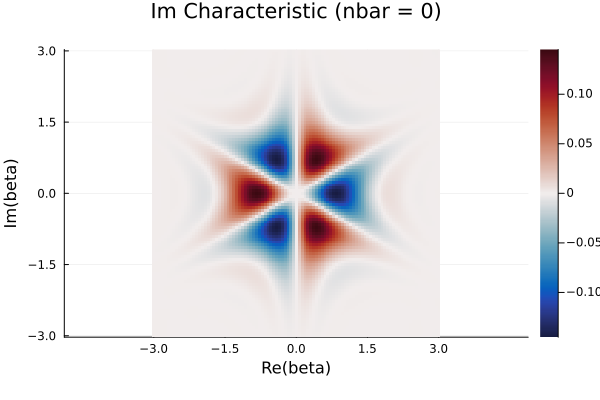

In [17]:
"""Plot imaginary part """
axis_ticks = (LinRange(beta_min, beta_max, 5), LinRange(beta_min, beta_max, 5))

axis_labels = ("Re(beta)", "Im(beta)")
chi_arr = get_characteristic_function_psi(psi_hybrid, beta_max, num_points, do_re=false)
plot_title = "Im Characteristic (nbar = 0)"
p = plot_char_fn(chi_arr, plot_title, axis_labels, axis_ticks)

Purity: 0.9999993019315394


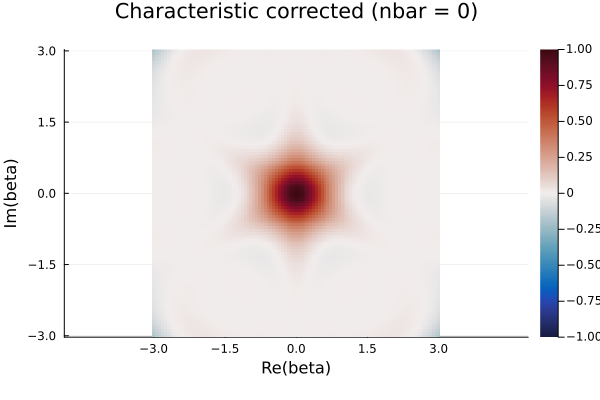

In [19]:
purity = get_purity_psi(psi_hybrid)
print("Purity: ", purity, "\n")
chi_corr_arr = get_numerator_psi(psi_hybrid, beta_max, num_points) / purity
plot_title = "Characteristic corrected (nbar = 0)"
p = plot_char_fn(chi_corr_arr, plot_title, axis_labels, axis_ticks)


Next go to mixed initial state. Start with thermal state

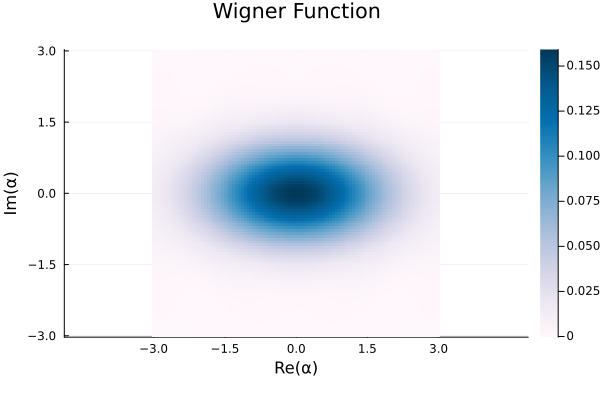

In [ ]:
nbar = 0.5
thermal_state = thermalstate_local(b_motion, nbar)
rho_m = tensor(thermal_state, thermal_state)
S1 = squeeze_one(0.3, 0, 1)
S2 = squeeze_one(0.3, pi/2, 2)
rho_m = S1*rho_m*S1'
rho_m = S2*rho_m*S2'
rho_hybrid = tensor(dm(up), rho_m)
rho_m1 = ptrace(rho_m, [2])
m1_w = plot_wigner(rho_m1)

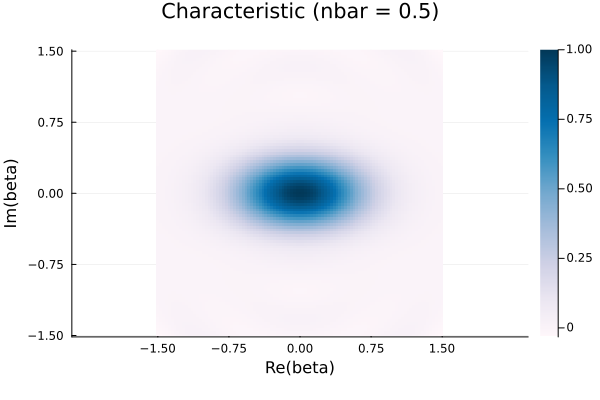

In [10]:
chi_arr = get_characteristic_function_rho(rho_hybrid, beta_max, num_points)
p = heatmap(linear_range, linear_range, real.(chi_arr), c=:PuBu_9, aspect_ratio=:equal, xlabel=axis_labels[1], ylabel=axis_labels[2], title="Characteristic (nbar = $(nbar))", xticks=axis_ticks[1], yticks=axis_ticks[2])

Purity: 0.4005128115144092


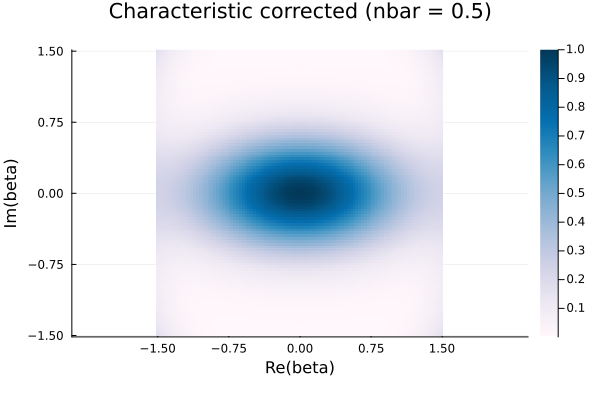

In [11]:
purity = get_purity_rho(rho_hybrid)
print("Purity: ", purity, "\n")
chi_corr_arr = get_numerator_rho(rho_hybrid, beta_max, num_points) / purity
p = heatmap(linear_range, linear_range, real.(chi_corr_arr), c=:PuBu_9, aspect_ratio=:equal, xlabel=axis_labels[1], ylabel=axis_labels[2], title="Characteristic corrected (nbar = $(nbar))", xticks=axis_ticks[1], yticks=axis_ticks[2])

Higher order squeezed states

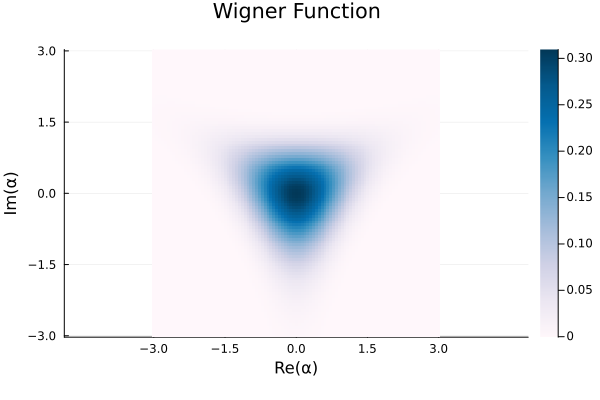

In [ ]:
function get_characteristic_function_psi_slice(psi, beta_max, phi, num_points)
    # mag of beta is range, angle is phi
    beta_mag_range = LinRange(0, beta_max, num_points)
    chi_arr = zeros(ComplexF64, num_points)
    Threads.@threads for i in 1:num_points
        beta = beta_mag_range[i] * exp(1im*phi)
        chi_arr[i] = get_chi_psi(psi, beta)
    end
    return chi_arr
end

function get_characteristic_function_rho_slice(rho, beta_max, phi, num_points)
    # mag of beta is range, angle is phi
    beta_mag_range = LinRange(0, beta_max, num_points)
    chi_arr = zeros(ComplexF64, num_points)
    Threads.@threads for i in 1:num_points
        beta = beta_mag_range[i] * exp(1im*phi)
        chi_arr[i] = get_chi_rho(rho, beta)
    end
    return chi_arr
end

function get_numerator_psi_slice(psi, beta_max, phi, num_points)
    # mag of beta is range, angle is phi
    beta_mag_range = LinRange(0, beta_max, num_points)
    chi_arr = zeros(ComplexF64, num_points)
    Threads.@threads for i in 1:num_points
        beta = beta_mag_range[i] * exp(1im*phi)
        chi_arr[i] = get_chi_corr_psi(psi, beta)
    end
    return chi_arr
end

function get_numerator_rho_slice(rho, beta_max, phi, num_points)
    # mag of beta is range, angle is phi
    beta_mag_range = LinRange(0, beta_max, num_points)
    chi_arr = zeros(ComplexF64, num_points)
    Threads.@threads for i in 1:num_points
        beta = beta_mag_range[i] * exp(1im*phi)
        chi_arr[i] = get_chi_corr_rho(rho, beta)
    end
    return chi_arr
end

Purity: 0.4000000000762582


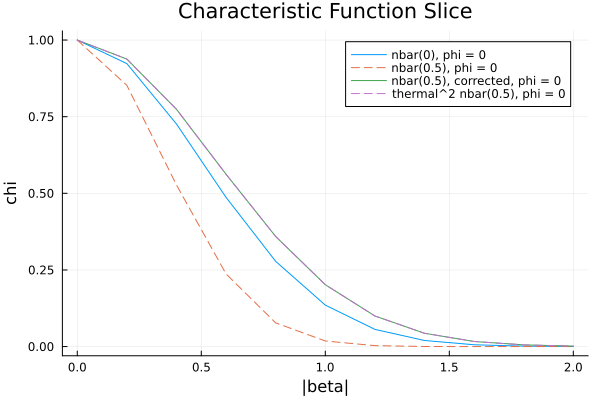

In [4]:
S = 0.0
phi_2 = 0.0
psi_m = coherentstate(b_motion, 0) ⊗ coherentstate(b_motion, 0)
psi_m = squeeze_one(S, 0, 1)*psi_m
psi_m = squeeze_one(S, phi_2, 2)*psi_m
psi_hybrid = tensor(up, psi_m)
# psi_flip = sdbs(pi/2,0)*sdbs(pi/2, 0)*psi_hybrid
# psi_m1 = ptrace(psi_m, [2])
# m1_w = plot_wigner(psi_m1)
# psi_m1 = ptrace(psi_flip, [1,3])
# m1_w = plot_wigner(psi_m1)

beta_max = 2.0
num_points = 11

phis = [pi/2, pi/3]
phi_labels = ["pi/2", "pi/3"]
phis = [0]#, pi/2]
phi_labels = ["0"]#, "pi/2"]
plot()
for (i, phi) in enumerate(phis)
    chi_arr = get_characteristic_function_psi_slice(psi_hybrid, beta_max, phi, num_points)
    p = plot!(LinRange(0, beta_max, num_points), real.(chi_arr), label="nbar(0), phi = $(phi_labels[i])", linestyle=:solid)
end

# purity = get_purity_psi(psi_hybrid)
# print("Purity: ", purity, "\n")
# plot()
# for (i, phi) in enumerate(phis)
#     chi_corr_arr = get_numerator_psi_slice(psi_hybrid, beta_max, phi, num_points) / purity
#     p = plot!(LinRange(0, beta_max, num_points), real.(chi_corr_arr), xlabel="|beta|", ylabel="Re(chi_corr)",  label="phi = $(phi_labels[i])", title="Characteristic Function Slice Corrected")
# end
# plot!(title="Characteristic Function Slice Corrected", legend=:topright)

nbar = 0.5
thermal_state = thermalstate_local(b_motion, nbar)
#fock_state = dm(fockstate(b_motion, 3))
rho_m = tensor(thermal_state, thermal_state)
S1 = squeeze_one(S, 0, 1)
S2 = squeeze_one(S, phi_2, 2)
rho_m = S1*rho_m*S1'
rho_m = S2*rho_m*S2'
rho_hybrid = tensor(dm(up), rho_m)
# rho_m1 = ptrace(rho_m, [2])
# m1_w = plot_wigner(rho_m1)

for (i, phi) in enumerate(phis)
    chi_arr = get_characteristic_function_rho_slice(rho_hybrid, beta_max, phi, num_points)
    p = plot!(LinRange(0, beta_max, num_points), real.(chi_arr), label="nbar($(nbar)), phi = $(phi_labels[i])", linestyle=:dash)
end

purity = get_purity_rho(rho_hybrid)
print("Purity: ", purity, "\n")
for (i, phi) in enumerate(phis)
    chi_corr_arr = get_numerator_rho_slice(rho_hybrid, beta_max, phi, num_points) / purity
    p = plot!(LinRange(0, beta_max, num_points), real.(chi_corr_arr),  label="nbar($(nbar)), corrected, phi = $(phi_labels[i])", linestyle=:solid)
end


# thermalsq_state = thermalsquarestate(b_motion, nbar)
# rho_m = tensor(thermalsq_state, thermalsq_state)
# S1 = squeeze_one(S, 0, 1)
# S2 = squeeze_one(S, 3*pi/6, 2)
# rho_m = S1*rho_m*S1'
# rho_m = S2*rho_m*S2'
# rho_hybrid = tensor(dm(up), rho_m)
# # rho_m1 = ptrace(rho_m, [2])
# # m1_w = plot_wigner(rho_m1)

# for (i, phi) in enumerate(phis)
#     chi_arr = get_characteristic_function_rho_slice(rho_hybrid, beta_max, phi, num_points)
#     p = plot!(LinRange(0, beta_max, num_points), real.(chi_arr), label="thermal^2 nbar($(nbar)), phi = $(phi_labels[i])", linestyle=:dash)
# end

thermalsqodd_state = thermalsquareoddstate(b_motion, nbar)
rho_m = tensor(thermalsqodd_state, thermalsqodd_state)
S1 = squeeze_one(S, 0, 1)
S2 = squeeze_one(S, 3*pi/6, 2)
rho_m = S1*rho_m*S1'
rho_m = S2*rho_m*S2'
rho_hybrid = tensor(dm(up), rho_m)
# rho_m1 = ptrace(rho_m, [2])
# m1_w = plot_wigner(rho_m1)

for (i, phi) in enumerate(phis)
    chi_arr = get_characteristic_function_rho_slice(rho_hybrid, beta_max, phi, num_points)
    p = plot!(LinRange(0, beta_max, num_points), real.(chi_arr), label="thermal^2 nbar($(nbar)), phi = $(phi_labels[i])", linestyle=:dash)
end
plot!(title="Characteristic Function Slice", legend=:topright, xlabel="|beta|", ylabel="chi",)


In [ ]:
# Error due to motional mode frequency drift
function get_characteristic_function_psi(psi, beta_max, num_points)
    beta_real_range = linear_range
    beta_imag_range = linear_range

    chi_arr = zeros(ComplexF64, num_points, num_points)

    Threads.@threads for idx in 1:(num_points * num_points)
        i = div(idx - 1, num_points) + 1
        j = mod(idx - 1, num_points) + 1

        beta = beta_real_range[i] + 1im * beta_imag_range[j]
        chi_arr[i, j] = get_chi_psi(psi, beta)
    end

    return chi_arr
end